# **ABUPINN - 6 capas con 64 neuronas**

## **1. Librerías usadas**

In [ ]:
#Starndard libreries
import os
import sys
import io
import time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random

#import libreries of NN
import tensorflow as tf
from tensorflow import keras
import tensorflow_probability as tfp

import tensorflow as tf
tf.keras.backend.set_floatx('float64') # Fuerza todo a 64 bits globalmente

#import optimization
from scipy.optimize import minimize
from scipy.interpolate import CubicSpline
import scipy.optimize


In [ ]:
# Define la ruta
path = '/content/ABUN_PINN'

# Crea la carpeta si no existe
if not os.path.exists(path):
    os.makedirs(path)
    print(f"Carpeta '{path}' creada con éxito.")
else:
    print(f"La carpeta '{path}' ya existe.")

Carpeta '/content/ABUN_PINN' creada con éxito.


## **2. Entrenamiento del la PINN**

In [ ]:
# Configurar semilla
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Parámetros físicos
sigma = 1.0
k0_sim = [1.0, 2.0, 5.0]
A_sim = [1.0, 1.0, 1.0]
k_boost = 0.0
m = 1.0
c = 1.0


#Parámetros iniciales
N = 12000
L = 80 * sigma
dx = L / N
T = L/2 - 4*sigma
dt = T / N

X_min, X_max = -L/2, L/2
T_min, T_max = 0.0, T

def condition_initial(x, sigma, k0, k_boost, m, A, dx):
    k0_arr = np.array(k0).reshape(-1, 1)
    A_arr = np.array(A).reshape(-1, 1)
    x_arr = x.reshape(1, -1)

    fase_estacionaria = np.sum(A_arr * np.exp(1j * k0_arr * x_arr) + A_arr * np.exp(-1j * k0_arr * x_arr), axis=0)
    fase_estacionaria = fase_estacionaria.reshape(-1, 1)

    psi_static = np.exp(-(x**2)/(2 * sigma**2)) * fase_estacionaria
    psi_moving = psi_static * np.exp(1j * k_boost * x)
    psi_moving = psi_moving / np.sqrt(np.max(np.abs(psi_moving)**2))

    phi0 = psi_moving.real
    phi0 = phi0 / np.sqrt(np.max(np.abs(phi0)**2))

    phi_k = np.fft.fft(psi_moving.flatten())
    k_freqs = 2 * np.pi * np.fft.fftfreq(len(x), d=dx)
    omega_k = np.sqrt(k_freqs**2 + m**2)

    pi_k_calc = -1j * omega_k * phi_k
    pi0 = np.fft.ifft(pi_k_calc).real.reshape(-1, 1)

    return phi0, pi0

# Interpolación de phi y pi
x_grid = np.linspace(X_min, X_max, 4000).reshape(-1, 1)
phi0_vals, pi0_vals = condition_initial(x_grid, sigma, k0_sim, k_boost, m, A_sim, dx)
interp_phi0 = CubicSpline(x_grid.flatten(), phi0_vals.flatten(), extrapolate=True)
interp_pi0  = CubicSpline(x_grid.flatten(), pi0_vals.flatten(), extrapolate=True)

In [ ]:
class AbuLayer(tf.keras.layers.Layer):
    def __init__(self, units, is_first_layer=False, omega_0=10.0, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.is_first_layer = is_first_layer
        self.omega_0 = omega_0

    def build(self, input_shape):
        glorot_init = tf.keras.initializers.GlorotNormal(seed=seed)

        # Inicializador SIREN para la rama seno/coseno
        siren_scale = 2.0 / (self.omega_0 ** 2)
        siren_init = tf.keras.initializers.VarianceScaling(
            scale=siren_scale, mode='fan_in', distribution='uniform', seed=seed)

        self.dense_siren = tf.keras.layers.Dense(self.units, dtype=tf.float32, kernel_initializer=siren_init)
        self.dense = tf.keras.layers.Dense(self.units, dtype=tf.float32, kernel_initializer=glorot_init)
        self.coeff = self.add_weight(shape=(4,), initializer=tf.keras.initializers.Constant(0.0),
                                     trainable=True, name="act_coeff", dtype=tf.float32)

    def call(self, inputs):
        z = self.dense(inputs)
        z_siren = self.dense_siren(inputs)

        a_sin = tf.math.sin(self.omega_0 * z_siren)
        a_cos = tf.math.cos(self.omega_0 * z_siren)
        a_tanh = tf.math.tanh(z)
        a_rat = tf.math.reciprocal(1.0 + tf.math.square(z))
        w = tf.nn.softmax(self.coeff)

        return a_sin * w[0] + a_cos * w[1] + a_tanh * w[2] + a_rat * w[3]

In [ ]:
@tf.keras.utils.register_keras_serializable()
class mABU_PINN(tf.keras.Model):
    def __init__(self, num_layers=5, hidden_dim=50, L=80.0, T_max=40.0,
                 X_min=-40.0, X_max=40.0, omega_0=10.0, **kwargs):
        super().__init__(**kwargs)
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.L = L
        self.omega_0 = omega_0

        self.T_max = tf.constant(T_max, dtype=tf.float32)
        self.X_min = tf.constant(X_min, dtype=tf.float32)
        self.X_max = tf.constant(X_max, dtype=tf.float32)

    def build(self, input_shape):
        # Encoders U y V (estilo Wang): proyectan la entrada al espacio oculto, se calculan UNA vez
        self.encoder_u = AbuLayer(self.hidden_dim, omega_0=self.omega_0, name="Encoder_U")
        self.encoder_v = AbuLayer(self.hidden_dim, omega_0=self.omega_0, name="Encoder_V")

        # Transformación inicial H^(1)
        self.input_transform = AbuLayer(self.hidden_dim, is_first_layer=True,
                                        omega_0=self.omega_0, name="Input_Transform")

        # Capas ocultas
        self.hidden_layers = [
            AbuLayer(self.hidden_dim, omega_0=self.omega_0, name=f"AbuLayer_{i}")
            for i in range(self.num_layers)
        ]
        self.out_layer = tf.keras.layers.Dense(1, dtype=tf.float32,
                                               kernel_initializer='glorot_uniform', name="Output")
        super().build(input_shape)

    def call(self, inputs):
        x = tf.cast(inputs[0], tf.float32)
        t = tf.cast(inputs[1], tf.float32)

        x_norm = 2.0 * (x - self.X_min) / (self.X_max - self.X_min) - 1.0
        t_norm = t / self.T_max
        inp = tf.concat([x_norm, t_norm], axis=-1)

        # Codificadores U y V
        U = self.encoder_u(inp)
        V = self.encoder_v(inp)

        # Estado oculto inicial
        H = self.input_transform(inp)

        # Núcleo de la modified MLP: mezcla con U y V en cada capa
        for layer in self.hidden_layers:
            Z = layer(H)
            H = (1.0 - Z) * U + Z * V

        N_xt = self.out_layer(H)

        # UPCAST a float64 para los residuos físicos
        return tf.cast(N_xt, tf.float64)

In [ ]:
def pde_loss_causal(model, x_f, t_f, c_val, m_val, epsilon=100.0, num_chunks=10):
    t_flat = tf.reshape(t_f, [-1])
    sorted_indices = tf.argsort(t_flat)

    t_f_sorted = tf.gather(t_f, sorted_indices)
    x_f_sorted = tf.gather(x_f, sorted_indices)

    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch([x_f_sorted, t_f_sorted])
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch([x_f_sorted, t_f_sorted])
            phi = model([x_f_sorted, t_f_sorted])

        phi_x = tape1.gradient(phi, x_f_sorted)
        phi_t = tape1.gradient(phi, t_f_sorted)

    phi_xx = tape2.gradient(phi_x, x_f_sorted)
    phi_tt = tape2.gradient(phi_t, t_f_sorted)
    del tape1, tape2

    # 3. RESIDUO BRUTO (Element-wise)
    c_tf = tf.cast(c_val, tf.float64)
    m_tf = tf.cast(m_val, tf.float64)

    # Residuo punto por punto (vector columna)
    residual = phi_tt - tf.square(c_tf) * phi_xx + tf.square(m_tf) * phi
    squared_residual = tf.square(residual)

    N_total = tf.shape(squared_residual)[0]
    chunk_size = N_total // num_chunks

    N_exact = chunk_size * num_chunks
    sq_res_trunc = squared_residual[:N_exact]
    chunks = tf.reshape(sq_res_trunc, [num_chunks, chunk_size])

    L_i = tf.reduce_mean(chunks, axis=1)
    cumulative_loss = tf.math.cumsum(L_i, exclusive=True)

    epsilon_tf = tf.constant(epsilon, dtype=tf.float64)
    causal_weights = tf.exp(-epsilon_tf * cumulative_loss)

    causal_weights = tf.stop_gradient(causal_weights)
    causal_loss = tf.reduce_mean(causal_weights * L_i)

    return causal_loss

def initial_condition_loss(model, x_ic, t_ic, phi0_tf, pi0_tf):
    with tf.GradientTape() as tape:
        tape.watch(t_ic)
        phi_pred = model([x_ic, t_ic])
    phi_t_pred = tape.gradient(phi_pred, t_ic)

    loss_phi = tf.reduce_mean(tf.square(phi_pred - phi0_tf))
    loss_pi  = tf.reduce_mean(tf.square(phi_t_pred - pi0_tf))
    return loss_phi, loss_pi

def boundary_condition_loss(model, t_bc, x_bc_left, x_bc_right):
    with tf.GradientTape() as tape_l:
        tape_l.watch(x_bc_left)
        phi_left = model([x_bc_left, t_bc])
    phi_x_left = tape_l.gradient(phi_left, x_bc_left)

    with tf.GradientTape() as tape_r:
        tape_r.watch(x_bc_right)
        phi_right = model([x_bc_right, t_bc])
    phi_x_right = tape_r.gradient(phi_right, x_bc_right)

    loss_val = tf.reduce_mean(tf.square(phi_left - phi_right))
    loss_der = tf.reduce_mean(tf.square(phi_x_left - phi_x_right))

    return loss_val + loss_der

In [ ]:
@tf.function(jit_compile=True ,reduce_retracing=True)
def train_step(model, optimizer, x_f, t_f, x_ic, t_ic, phi0, pi0, x_bc_l, x_bc_r, t_bc, c_tf, m_tf, alpha_lra,
               c_phi=0.0, c_pi=0.0, c_bc = 0.0, w_tensor=[1.0 ,1.0 ,1.0 ,1.0], epsilon = 1.0, num_chunks = 16):
    with tf.GradientTape(persistent=True) as tape:
        lf = pde_loss_causal(model, x_f, t_f, c_tf, m_tf, epsilon= epsilon, num_chunks= num_chunks)
        l_phi, l_pi = initial_condition_loss(model, x_ic, t_ic, phi0, pi0)
        lb = boundary_condition_loss(model, t_bc, x_bc_l, x_bc_r)

        total_loss = w_tensor[0]*lf + w_tensor[1]*l_phi + w_tensor[2]*l_pi + w_tensor[3]*lb
        tf.debugging.check_numerics(total_loss, "total_loss NaN/Inf")

    #Algoritmo de LRA
    target_layer_vars = model.trainable_variables[-2]

    grad_f = tape.gradient(lf, target_layer_vars)
    grad_phi = tape.gradient(l_phi, target_layer_vars)
    grad_pi = tape.gradient(l_pi, target_layer_vars)
    grad_b = tape.gradient(lb, target_layer_vars)

    max_f = tf.cast(tf.reduce_max(tf.abs(grad_f)), tf.float64)
    mean_phi = tf.cast(tf.reduce_mean(tf.abs(grad_phi)), tf.float64)
    mean_pi = tf.cast(tf.reduce_mean(tf.abs(grad_pi)), tf.float64)
    mean_b = tf.cast(tf.reduce_mean(tf.abs(grad_b)), tf.float64)

    eps = tf.constant(np.finfo(float).eps, dtype=tf.float64)

    #Por si las moscas
    den_phi = mean_phi + c_phi*max_f
    den_pi = mean_pi + c_pi*max_f
    den_bc = mean_b + c_bc-max_f

    # Calculamos los multiplicadores crudos
    lamb_phi = max_f / (den_phi + eps)
    lamb_pi = max_f / (den_pi + eps)
    lamb_b = max_f / (den_bc + eps)

    lamb_phi = tf.clip_by_value(lamb_phi, 1e-1, 1e+2)
    lamb_pi  = tf.clip_by_value(lamb_pi,  1e-2, 1e+1)
    lamb_b  = tf.clip_by_value(lamb_b,  1e-3, 1e-1)

    # Actualizamos los pesos mediante Media Móvil (EMA) directamente en la GPU
    w_phi_new = (1.0 - alpha_lra) * w_tensor[1] + alpha_lra * lamb_phi
    w_pi_new = (1.0 - alpha_lra) * w_tensor[2] + alpha_lra * lamb_pi
    w_bc_new = (1.0 - alpha_lra) * w_tensor[3] + alpha_lra * lamb_b

    # Asignamos los nuevos pesos a la variable global (Entrarán en efecto en la próxima época)
    w_tensor.assign([w_tensor[0], w_phi_new, w_pi_new, w_bc_new])

    # OPTIMIZACIÓN
    grads = tape.gradient(total_loss, model.trainable_variables)
    del tape

    grads = [tf.zeros_like(v) if g is None else g for g, v in zip(grads, model.trainable_variables)]
    grads, gnorm = tf.clip_by_global_norm(grads, 50.0)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    return total_loss, lf, l_phi, l_pi, lb, gnorm

def resample_all_focused(n_phys, n_bc, n_ic, focus=True):
    """ Muestreo focalizado: cono+global para PDE, gaussiano+uniforme para IC """

    # ============ PDE: 80% cono de luz + 20% global ============
    if focus:
        n_cone = int(0.8 * n_phys)
        n_global = n_phys - n_cone

        # Cono (alta densidad donde hay acción)
        t_cone = np.random.uniform(0.0, T_max, (n_cone, 1)).astype(np.float64)
        margen = 5.0
        radios = sigma + c * t_cone + margen
        radios = np.clip(radios, 0.0, X_max)
        u = np.random.uniform(-1.0, 1.0, (n_cone, 1)).astype(np.float64)
        x_cone = u * radios

        # Global (enseña φ≈0 fuera del cono)
        t_global = np.random.uniform(0.0, T_max, (n_global, 1)).astype(np.float64)
        x_global = np.random.uniform(X_min, X_max, (n_global, 1)).astype(np.float64)

        x_f_new = np.concatenate([x_cone, x_global], axis=0)
        t_f_new = np.concatenate([t_cone, t_global], axis=0)
    else:
        t_f_new = np.random.uniform(0.0, T_max, (n_phys, 1)).astype(np.float64)
        x_f_new = np.random.uniform(X_min, X_max, (n_phys, 1)).astype(np.float64)

    # ============ BC: fronteras ============
    t_bc_new = np.random.uniform(0.0, T_max, (n_bc, 1)).astype(np.float64)
    x_bc_l_new = np.full((n_bc, 1), X_min, dtype=np.float64)
    x_bc_r_new = np.full((n_bc, 1), X_max, dtype=np.float64)

    # ============ IC: 80% gaussiano + 20% uniforme ============
    if focus:
        n_ic_focus = int(0.8 * n_ic)
        n_ic_unif  = n_ic - n_ic_focus
        x_ic_focus = np.clip(np.random.normal(0.0, 4.0 * sigma, (n_ic_focus, 1)),
                             X_min, X_max)
        x_ic_unif  = np.random.uniform(X_min, X_max, (n_ic_unif, 1))
        x_ic_new   = np.concatenate([x_ic_focus, x_ic_unif], axis=0).astype(np.float64)
    else:
        x_ic_new = np.random.uniform(X_min, X_max, (n_ic, 1)).astype(np.float64)

    t_ic_new = np.zeros((n_ic, 1), dtype=np.float64)
    phi0_new = interp_phi0(x_ic_new.flatten()).reshape(-1, 1).astype(np.float64)
    pi0_new  = interp_pi0(x_ic_new.flatten()).reshape(-1, 1).astype(np.float64)

    return (tf.constant(x_f_new), tf.constant(t_f_new),
            tf.constant(x_ic_new), tf.constant(t_ic_new),
            tf.constant(phi0_new), tf.constant(pi0_new),
            tf.constant(x_bc_l_new), tf.constant(x_bc_r_new), tf.constant(t_bc_new))

In [ ]:
@tf.function(reduce_retracing=True)
def get_loss_and_grads_lbfgs(x_f, t_f, x_ic, t_ic, phi0, pi0, x_bc_l, x_bc_r, t_bc, c_tf, m_tf, epsilon, num_chunks):
    with tf.GradientTape() as tape:
        lf = pde_loss_causal(model, x_f, t_f, c_tf, m_tf, epsilon = epsilon, num_chunks= num_chunks)
        l_phi, l_pi = initial_condition_loss(model, x_ic, t_ic, phi0, pi0)
        lb = boundary_condition_loss(model, t_bc, x_bc_l, x_bc_r)
        total_loss = lf + l_phi + l_pi + lb

    grads = tape.gradient(total_loss, model.trainable_variables)

    # Aplanamos los gradientes y los escalamos a Float64 para L-BFGS (Scipy lo requiere)
    flat_grads = tf.cast(tf.concat([tf.reshape(g, [-1]) for g in grads if g is not None], axis=0), tf.float64)

    return total_loss, lf, l_phi, l_pi, lb, flat_grads


def set_flat_weights(model, flat_weights):
    flat_weights = tf.cast(flat_weights, tf.float32)
    start = 0
    for w in model.trainable_variables:
        shape = w.shape
        size = tf.reduce_prod(shape)
        new_w = tf.reshape(flat_weights[start:start + size], shape)
        w.assign(new_w)
        start += size


def get_flat_weights(model):
    weights = [tf.reshape(tf.cast(w, tf.float64), [-1]) for w in model.trainable_variables]
    return tf.concat(weights, axis=0).numpy()


def lbfgs_objective(flat_weights, x_f, t_f, x_ic, t_ic, phi0, pi0,
                    x_bc_l, x_bc_r, t_bc, c_tf, m_tf, epsilon, num_chunks):
    set_flat_weights(model, flat_weights)
    t_loss, lf, l_phi, l_pi, lb, grads = get_loss_and_grads_lbfgs(
        x_f, t_f, x_ic, t_ic, phi0, pi0, x_bc_l, x_bc_r, t_bc,
        c_tf, m_tf, epsilon, num_chunks
    )

    loss_val = t_loss.numpy().astype(np.float64)
    grads_val = grads.numpy().astype(np.float64)

    global lbfgs_iter
    lbfgs_iter += 1

    if lbfgs_iter % 100 == 0:
        print(f"L-BFGS Iter {lbfgs_iter} | Total Loss={loss_val:.2e} | "
              f"PDE={lf:.2e} | PHI={l_phi:.2e} | PI={l_pi:.2e} | BC={lb:.2e}")
        loss_history["epoch"].append(epochs_adam + lbfgs_iter)
        loss_history["total"].append(loss_val)
        loss_history["pde"].append(lf.numpy())
        loss_history["phi"].append(l_phi.numpy())
        loss_history["pi"].append(l_pi.numpy())
        loss_history["bc"].append(lb.numpy())

    return loss_val, grads_val

In [ ]:
#Seed
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Parámetros de ejecución
neurons = 64
num_blocks = 6
epochs_adam = 100000
max_iter_lbfgs = 0
print_every = 1000
as_freq = 1
stop_resampling = epochs_adam
n_phys = N
n_bc = N // 4
n_ic = N // 2

#LRA
alpha_lra = 0.9
w_tensor = tf.Variable([1.0, 1.0, 1.0, 1e-1], dtype=tf.float64)

#SIREN
omega_0 = 15.0

#Causal Training
epsilon = 10.0
num_chunks = 16

# Instanciar modelo
model = mABU_PINN(num_layers=num_blocks, hidden_dim=neurons, omega_0 = omega_0)

# Forzar inicialización construyendo las capas
x_f, t_f, x_ic, t_ic, phi0, pi0, x_bc_l, x_bc_r, t_bc = resample_all_focused(n_phys, n_bc, n_ic, focus=True)
_ = model([x_f, t_f])

# Optimizador
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3, decay_steps=2000, decay_rate=0.9, staircase=False
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)
optimizer.build(model.trainable_variables)

# Historial principal
loss_history = {"epoch": [], "total": [], "pde": [], "phi": [], "pi": [] ,"bc": [], "lambda_phi": [], "lambda_pi":[], "lambda_bc": []}

# Funciones de pérdida

c_tf = tf.cast(c, tf.float64)
m_tf = tf.cast(m, tf.float64)

# Muestreo inicial
x_f, t_f, x_ic, t_ic, phi0, pi0, x_bc_l, x_bc_r, t_bc = resample_all_focused(n_phys, n_bc, n_ic, focus=True)

start_time = time.time()

print(" FASE 1: Exploración Global con Adam + LRA")

stop_focus = epochs_adam * 0.8

for epoch in range(1, epochs_adam + 1):

    if epoch % as_freq == 0 and epoch <= stop_resampling:
        # Usar muestreo enfocado al principio, muestreo global al final
        current_focus = True if epoch <= stop_focus else False

        x_f, t_f, x_ic, t_ic, phi0, pi0, x_bc_l, x_bc_r, t_bc = resample_all_focused(
            n_phys, n_bc, n_ic, focus=current_focus
        )

    t_loss, lf, l_phi, l_pi, lb, gnorm = train_step(
        model, optimizer, x_f, t_f, x_ic, t_ic, phi0, pi0, x_bc_l, x_bc_r, t_bc, c_tf, m_tf, w_tensor = w_tensor, alpha_lra = alpha_lra, epsilon = epsilon, num_chunks = num_chunks
    )

    if epoch % print_every == 0 or epoch == 1:
        elapsed = time.time() - start_time
        print(f"AdamW Ep {epoch}/{epochs_adam} | Total={t_loss:.2e} | PDE={lf:.2e} | PHI={l_phi:.2e} | PI = {l_pi:.2e} | BC={lb:.2e} | w_phi={w_tensor[1]:.2e} | w_pi={w_tensor[2]:.2e} | w_bc={w_tensor[3]:.2e} | gnorm ={gnorm:.2e} | LR={lr_schedule(optimizer.iterations):.2e} | Time: {elapsed:.1f}s")

        # Guardado del histórico para AdamW
        loss_history["epoch"].append(epoch)
        loss_history["total"].append(t_loss.numpy())
        loss_history["pde"].append(lf.numpy())
        loss_history["phi"].append((l_phi ).numpy())
        loss_history["pi"].append((l_pi).numpy())
        loss_history["bc"].append(lb.numpy())
        loss_history["lambda_phi"].append(w_tensor[1].numpy())
        loss_history["lambda_pi"].append(w_tensor[2].numpy())
        loss_history["lambda_bc"].append(w_tensor[3].numpy())


if max_iter_lbfgs == 0:
  pass
else:
  print("\n FASE 2: Refinamiento Fino con L-BFGS")
  lbfgs_iter = 0
  initial_weights = get_flat_weights(model)


  results = scipy.optimize.minimize(
      fun=lbfgs_objective,
      x0=initial_weights,
      args=(x_f, t_f, x_ic, t_ic, phi0, pi0, x_bc_l, x_bc_r, t_bc, c_tf, m_tf, epsilon, num_chunks),
      method='L-BFGS-B',
      jac=True,
      options={
          'maxiter': max_iter_lbfgs,
          'maxfun': max_iter_lbfgs,
          'ftol': 1.0 * np.finfo(float).eps,
          'gtol': 1e-8
      }
  )
  set_flat_weights(model, tf.convert_to_tensor(results.x, dtype=tf.float64))
  print(f"\nL-BFGS Finalizado: {results.message}")
  print(f"Pérdida final alcanzada: {results.fun:.2e}")

# GUARDADO
valid_history = {k: v for k, v in loss_history.items() if len(v) > 0}
min_len = min([len(v) for v in valid_history.values()])
clean_history = {k: v[:min_len] for k, v in valid_history.items()}
df_loss = pd.DataFrame(clean_history)
df_loss.to_csv("training_loss_history_AbuPINN.csv", index=False)

# Guardamos los pesos del modelo
model.save_weights("AbuPINN_ultimate_weights.weights.h5")

print(f"Entrenamiento finalizado exitosamente y guardado (Filas guardadas: {min_len}).")

 FASE 1: Exploración Global con Adam + LRA
AdamW Ep 1/100000 | Total=5.94e-01 | PDE=2.71e-02 | PHI=5.24e-01 | PI = 6.89e-05 | BC=4.33e-01 | w_phi=1.90e-01 | w_pi=9.10e+00 | w_bc=9.85e-02 | gnorm =8.37e+00 | LR=1.00e-03 | Time: 133.7s
AdamW Ep 1000/100000 | Total=8.50e-02 | PDE=1.24e-02 | PHI=1.52e-03 | PI = 3.49e-04 | BC=2.03e-03 | w_phi=9.86e+00 | w_pi=1.00e+01 | w_bc=1.00e-03 | gnorm =2.46e+01 | LR=9.49e-04 | Time: 152.2s
AdamW Ep 2000/100000 | Total=1.49e-02 | PDE=4.50e-03 | PHI=1.55e-03 | PI = 5.44e-04 | BC=7.22e-04 | w_phi=3.60e+00 | w_pi=1.00e+01 | w_bc=1.09e-03 | gnorm =2.26e+00 | LR=9.00e-04 | Time: 170.2s
AdamW Ep 3000/100000 | Total=3.23e-03 | PDE=2.19e-03 | PHI=1.02e-04 | PI = 2.59e-05 | BC=1.92e-04 | w_phi=2.21e+01 | w_pi=1.00e+01 | w_bc=9.90e-02 | gnorm =1.26e+00 | LR=8.54e-04 | Time: 188.1s
AdamW Ep 4000/100000 | Total=2.51e-03 | PDE=1.44e-03 | PHI=4.43e-05 | PI = 1.00e-04 | BC=7.91e-05 | w_phi=3.90e+00 | w_pi=9.97e+00 | w_bc=1.10e-03 | gnorm =3.50e+00 | LR=8.10e-04 | Tim

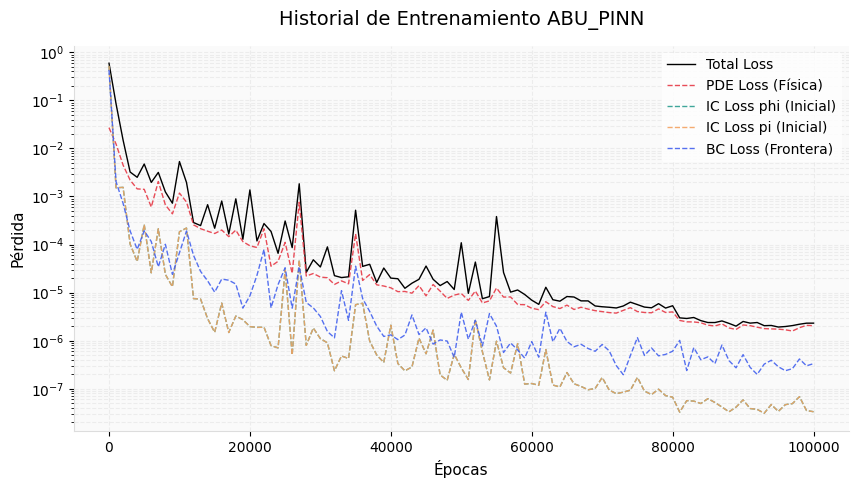

In [ ]:
import matplotlib.pyplot as plt

# Gráfica de Convergencia
plt.figure(figsize=(10, 5))

# Paleta de tonos pastel enfocada en aqua, verdes y azules
color_total  = "#000000" # Negro intenso
color_pde    = "#E63946" # Rojo carmesí vibrante
color_ic_phi = "#2A9D8F" # Verde esmeralda sólido
color_ic_pi  = "#F4A261" # Naranja fuerte
color_bc     = "#4361EE" # Azul rey puro

plt.semilogy(loss_history["epoch"], loss_history["total"], color=color_total, label="Total Loss", linewidth=1)
plt.semilogy(loss_history["epoch"], loss_history["pde"], color=color_pde, label="PDE Loss (Física)", linestyle="--", alpha=0.9, linewidth=1)
plt.semilogy(loss_history["epoch"], loss_history["phi"], color=color_ic_phi, label="IC Loss phi (Inicial)", linestyle="--", alpha=0.9, linewidth=1)
plt.semilogy(loss_history["epoch"], loss_history["phi"], color=color_ic_pi, label="IC Loss pi (Inicial)", linestyle="--", alpha=0.9, linewidth=1)
plt.semilogy(loss_history["epoch"], loss_history["bc"], color=color_bc, label="BC Loss (Frontera)", linestyle="--", alpha=0.9, linewidth=1)

plt.title("Historial de Entrenamiento ABU_PINN", fontsize=14, pad=15)
plt.xlabel("Épocas", fontsize=11)
plt.ylabel("Pérdida", fontsize=11)

# Estilizar la leyenda para que se vea más limpia
plt.legend(frameon=True, facecolor='#ffffff', edgecolor='none', fontsize=10)

# Suavizar la cuadrícula y darle un fondo sutil a los ejes para resaltar los pasteles
plt.grid(True, which="both", ls="--", alpha=0.5, color='#E0E0E0')
plt.gca().set_facecolor('#FAFAFA')

# Quitar los bordes superior y derecho para un look más moderno
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#DDDDDD')
plt.gca().spines['bottom'].set_color('#DDDDDD')

plt.show()

In [ ]:
# Nombre correcto basado en tu captura de archivos: AbuPINN (sin 'n' extra)
nombre_archivo = f"AbuPINN_ultimate_weights.weights.h5"
ruta_completa = os.path.join("/content", nombre_archivo)

if os.path.exists(ruta_completa):
    try:
        model.load_weights(ruta_completa)
        print(f"   -> ¡ÉXITO! Pesos cargados desde: {nombre_archivo}")
    except Exception as e:
        print(f"\n[ERROR CRÍTICO]: El archivo existe pero no pudo ser leído: {e}")
else:
    print(f"\n[ERROR]: El archivo '{nombre_archivo}' NO existe en /content/ABUN_PINN/")
    print("Archivos encontrados en la carpeta:")
    print(os.listdir("/content/ABUN_PINN/"))
    # No uses sys.exit() aquí si quieres continuar con pesos aleatorios
    print("   -> Procediendo con inicialización aleatoria.")

   -> ¡ÉXITO! Pesos cargados desde: AbuPINN_ultimate_weights.weights.h5


In [ ]:
# Parámetros físicos
sigma = 1.0
k0_sim = [1.0, 2.0, 5.0]
A_sim = [1.0, 1.0, 1.0]
k_boost = 0.0
m = 1.0
c = 1.0

# Parámetros numéricos
N = 4096                    # puntos espaciales
L = 80 * sigma              # tamaño del dominio
T_max = L/2 - 4*sigma       # tiempo final (evita que el frente toque el borde)
n_t = 200                   # snapshots a guardar

# ============== MALLADO ==============
x = np.linspace(-L/2, L/2, N, endpoint=False)
dx = x[1] - x[0]
k = 2 * np.pi * np.fft.fftfreq(N, d=dx)

# Frecuencia angular de Klein-Gordon: cada modo k oscila a ω_k = √(c²k² + m²)
omega_k = np.sqrt(c**2 * k**2 + m**2)

# ============== CONDICIÓN INICIAL ==============
# Envolvente gaussiana modulada por suma de modos cosenoidales
k0_arr = np.array(k0_sim).reshape(-1, 1)
A_arr = np.array(A_sim).reshape(-1, 1)
x_row = x.reshape(1, -1)

fase = np.sum(A_arr * (np.exp(1j * k0_arr * x_row) + np.exp(-1j * k0_arr * x_row)), axis=0)
psi_static = np.exp(-x**2 / (2 * sigma**2)) * fase
psi_moving = psi_static * np.exp(1j * k_boost * x)
psi_moving = psi_moving / np.sqrt(np.max(np.abs(psi_moving)**2))

phi0 = psi_moving.real
phi0 = phi0 / np.sqrt(np.max(np.abs(phi0)**2))

# π₀ = ∂φ/∂t|_{t=0} consistente con la relación de dispersión KG
phi_k_aux = np.fft.fft(psi_moving)
pi_k_aux = -1j * omega_k * phi_k_aux
pi0 = np.fft.ifft(pi_k_aux).real

# ============== PROPAGACIÓN EXACTA ==============
phi_k_0 = np.fft.fft(phi0)
pi_k_0 = np.fft.fft(pi0)

t_save = np.linspace(0.0, T_max, n_t)
Z_exact = np.zeros((n_t, N))

# Manejo del límite ω_k → 0 (solo ocurre si m=0 y k=0)
small = np.isclose(omega_k, 0.0)
omega_safe = np.where(small, 1.0, omega_k)

for i, t in enumerate(t_save):
    cos_wt = np.cos(omega_k * t)
    sin_wt = np.sin(omega_k * t)
    sin_wt_div_w = sin_wt / omega_safe
    sin_wt_div_w[small] = t  # lim_{ω→0} sin(ωt)/ω = t

    # Propagación exacta de cada modo de Fourier
    phi_k_t = phi_k_0 * cos_wt + pi_k_0 * sin_wt_div_w
    Z_exact[i, :] = np.fft.ifft(phi_k_t).real



>>> Error Relativo L2 vs Referencia Pseudo-Espectral: 3.2173e-02 <<<


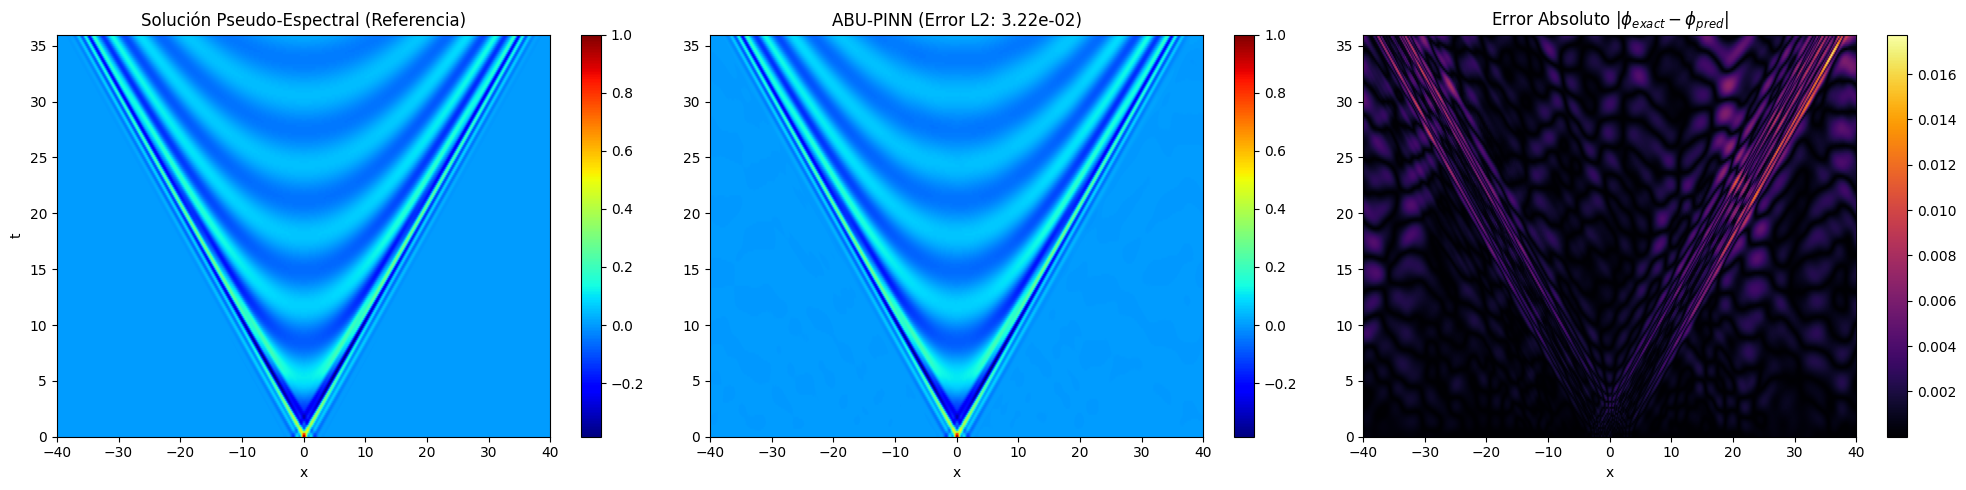

In [ ]:
# 1. Parámetros del dominio (deben coincidir con el solver pseudo-espectral)
sigma = 1.0
L = 80 * sigma
X_min, X_max = -L/2, L/2
T_min, T_max = 0.0, L/2 - 4*sigma
N = 4096    # Puntos espaciales de la FFT (debe coincidir con el solver)
n_t = 200   # Snapshots almacenados

# 2. Generar la malla de prueba
# IMPORTANTE: endpoint=False en x para respetar la periodicidad de la FFT
x_test_phys = np.linspace(X_min, X_max, N, endpoint=False)
t_test_phys = np.linspace(T_min, T_max, n_t)
X_grid, T_grid = np.meshgrid(x_test_phys, t_test_phys)

# Z_exact debe haber sido calculado previamente con el solver pseudo-espectral
# (shape (n_t, N))

# 3. Predicción del modelo ABU-PINN
X_input = tf.cast(X_grid.reshape(-1, 1), tf.float64)
T_input = tf.cast(T_grid.reshape(-1, 1), tf.float64)

pred_out = model([X_input, T_input]).numpy()
Z_pred = pred_out.flatten().reshape(n_t, N)

# 4. Error Relativo L2
error_l2 = np.linalg.norm(Z_exact - Z_pred, ord='fro') / np.linalg.norm(Z_exact, ord='fro')
print(f"\n>>> Error Relativo L2 vs Referencia Pseudo-Espectral: {error_l2:.4e} <<<")

# 5. Graficar
extent = [X_min, X_max, T_min, T_max]
vmax = max(np.abs(Z_exact).max(), np.abs(Z_pred).max())

fig, axs = plt.subplots(1, 3, figsize=(20, 5))
cmap = "jet"

# Solución de referencia
im1 = axs[0].imshow(Z_exact, extent=extent, aspect='auto', origin='lower',
                    cmap=cmap)
axs[0].set_title("Solución Pseudo-Espectral (Referencia)")
axs[0].set_xlabel("x")
axs[0].set_ylabel("t")
plt.colorbar(im1, ax=axs[0])

# Predicción de la PINN
im2 = axs[1].imshow(Z_pred, extent=extent, aspect='auto', origin='lower',
                    cmap=cmap)
axs[1].set_title(f"ABU-PINN (Error L2: {error_l2:.2e})")
axs[1].set_xlabel("x")
plt.colorbar(im2, ax=axs[1])

# Error absoluto
im3 = axs[2].imshow(np.abs(Z_exact - Z_pred), extent=extent, aspect='auto',
                    origin='lower', cmap='inferno')
axs[2].set_title(r"Error Absoluto $|\phi_{exact} - \phi_{pred}|$")
axs[2].set_xlabel("x")
plt.colorbar(im3, ax=axs[2])

plt.tight_layout()
plt.show()

In [ ]:
# Guardar el modelo completo de Keras
modelo_path = '/content/mABUPINN_model.keras'
model.save(modelo_path)
print(f"Modelo completo guardado exitosamente en: {modelo_path}")

Modelo completo guardado exitosamente en: /content/mABUPINN_model.keras


In [ ]:
# Calcular el error absoluto medio (Mean Absolute Error)
error_abs = np.mean(np.abs(Z_exact - Z_pred))

# Número de parámetros del modelo
num_params = model.count_params()

# Función de costo promedio de las última capa
costo = df_loss['total'].iloc[-1]

# Crear la tabla de errores ampliada
df_errores = pd.DataFrame(
    {
        "Error Relativo L2": [f"{error_l2:.2f}"],
        "Error Absoluto": [f"{error_abs:.4f}"],
        "Número de parámetros": [f"{num_params}"],
        "Costo final": [f"{costo:.2e}"]
    },
    index=["mABU-PINN"]
)

# Mostrar la tabla
df_errores

,Error Relativo L2,Error Absoluto,Número de parámetros,Costo final
mABU-PINN,0.03,0.0013,51173,2.31e-06


In [ ]:
# Guardar la tabla de errores en un archivo CSV
csv_path = '/content/errores_mABUPINN.csv'
df_errores.to_csv(csv_path, index=True)
print(f"Tabla de errores guardada exitosamente en: {csv_path}")

Tabla de errores guardada exitosamente en: /content/errores_mABUPINN.csv
